In [1]:
import pandas as pd
import sys
sys.path.append("./../src")
import utils
from setfit import SetFitModel
import ollama
from rouge_score import rouge_scorer
import requests
import json
import umap
import numpy as n
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt

In [2]:
sentences = [
    # In favour of nuclear energy
    "Nuclear energy is essential because it provides a reliable, low-carbon power source that can operate continuously.",
    "Nuclear energy is crucial as it delivers stable, low-emission electricity that can run day and night.",
    "Nuclear energy is important since it offers consistent, zero-carbon power that remains available at all times.",

    # Strongly opposing nuclear energy
    "Nuclear energy is dangerous because it creates long-lasting radioactive waste and exposes societies to catastrophic risks.",
    "Nuclear energy is unacceptable since it produces hazardous nuclear waste and threatens communities with severe accidents.",
    "Nuclear energy is reckless as it leaves behind toxic radioactive materials and endangers millions in case of failures."
]

parties = ["pro"] * 3 + ["con"] * 3

df = pd.DataFrame({"text": sentences, "party": parties})
df

,text,party
0,Nuclear energy is essential because it provide...,pro
1,Nuclear energy is crucial as it delivers stabl...,pro
2,Nuclear energy is important since it offers co...,pro
3,Nuclear energy is dangerous because it creates...,con
4,Nuclear energy is unacceptable since it produc...,con
5,Nuclear energy is reckless as it leaves behind...,con


In [3]:
# 1. Load model
model = SentenceTransformer("all-MiniLM-L6-v2")


In [7]:

# 2. Encode sentences
embeddings = model.encode(sentences)
print("Embeddings shape:", embeddings.shape)   # e.g., (10, 384)

# 3. Reduce dimensionality with UMAP
reducer = umap.UMAP(
    n_neighbors=10,      # how local the structure is
    min_dist=0.1,        # how tightly points can be packed
    n_components=2,      # output dims (2D or 3D)
    metric="cosine"      # recommended for sentence embeddings
)

embeddings_2d = reducer.fit_transform(embeddings)
print("UMAP shape:", embeddings_2d.shape)
print(embeddings_2d)

Embeddings shape: (6, 384)
UMAP shape: (6, 2)
[[5.8299437 6.894533 ]
 [6.357355  7.4765344]
 [5.711874  8.003842 ]
 [7.416731  7.659947 ]
 [7.165671  8.565619 ]
 [8.0349655 8.210921 ]]


/Users/andreacristiano/Desktop/VNIVERSITA/MAGISTRALE 2 ANNO/Big Data analytics/stance-detection-eu-parliaments/.venv/lib/python3.13/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


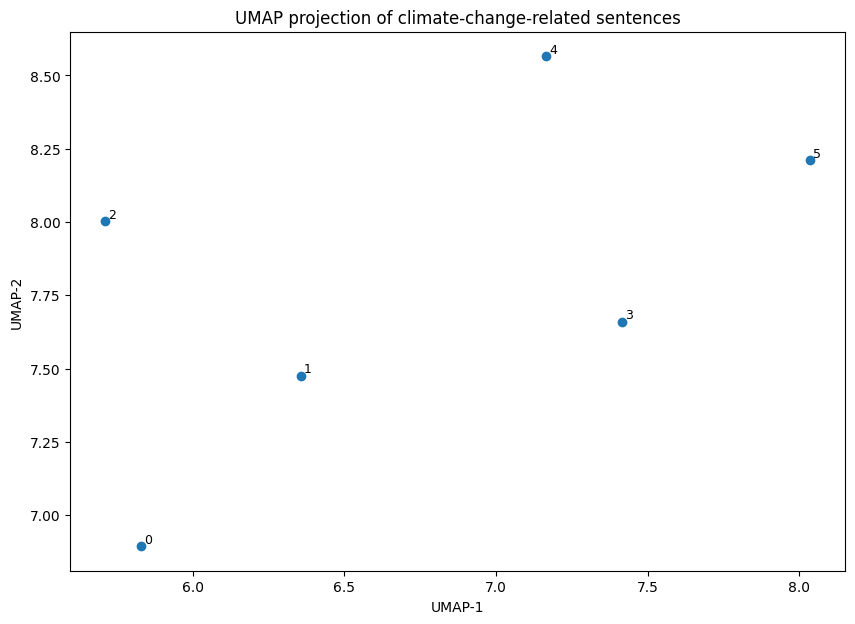

In [8]:
# 4. Plot
plt.figure(figsize=(10, 7))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1])

# Add labels
for i, sentence in enumerate(sentences):
    plt.text(
        embeddings_2d[i, 0] + 0.01,
        embeddings_2d[i, 1] + 0.01,
        str(i),
        fontsize=9
    )

plt.title("UMAP projection of climate-change-related sentences")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()